In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

In [2]:
df = pd.read_excel("EastWestAirlines.xlsx", sheet_name=1)

df.head()

,ID#,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?
0,1,28143,0,1,1,1,174,1,0,0,7000,0
1,2,19244,0,1,1,1,215,2,0,0,6968,0
2,3,41354,0,1,1,1,4123,4,0,0,7034,0
3,4,14776,0,1,1,1,500,1,0,0,6952,0
4,5,97752,0,4,1,1,43300,26,2077,4,6935,1


In [3]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3999 entries, 0 to 3998
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   ID#                3999 non-null   int64
 1   Balance            3999 non-null   int64
 2   Qual_miles         3999 non-null   int64
 3   cc1_miles          3999 non-null   int64
 4   cc2_miles          3999 non-null   int64
 5   cc3_miles          3999 non-null   int64
 6   Bonus_miles        3999 non-null   int64
 7   Bonus_trans        3999 non-null   int64
 8   Flight_miles_12mo  3999 non-null   int64
 9   Flight_trans_12    3999 non-null   int64
 10  Days_since_enroll  3999 non-null   int64
 11  Award?             3999 non-null   int64
dtypes: int64(12)
memory usage: 375.0 KB


,ID#,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?
count,3999.000000,3.999000e+03,3999.000000,3999.000000,3999.000000,3999.000000,3999.000000,3999.00000,3999.000000,3999.000000,3999.00000,3999.000000
mean,2014.819455,7.360133e+04,144.114529,2.059515,1.014504,1.012253,17144.846212,11.60190,460.055764,1.373593,4118.55939,0.370343
std,1160.764358,1.007757e+05,773.663804,1.376919,0.147650,0.195241,24150.967826,9.60381,1400.209171,3.793172,2065.13454,0.482957
min,1.000000,0.000000e+00,0.000000,1.000000,1.000000,1.000000,0.000000,0.00000,0.000000,0.000000,2.00000,0.000000
25%,1010.500000,1.852750e+04,0.000000,1.000000,1.000000,1.000000,1250.000000,3.00000,0.000000,0.000000,2330.00000,0.000000
50%,2016.000000,4.309700e+04,0.000000,1.000000,1.000000,1.000000,7171.000000,12.00000,0.000000,0.000000,4096.00000,0.000000
75%,3020.500000,9.240400e+04,0.000000,3.000000,1.000000,1.000000,23800.500000,17.00000,311.000000,1.000000,5790.50000,1.000000
max,4021.000000,1.704838e+06,11148.000000,5.000000,3.000000,5.000000,263685.000000,86.00000,30817.000000,53.000000,8296.00000,1.000000


In [4]:
df = df.drop(columns=["ID#"], errors='ignore')

In [5]:
df.isnull().sum()

Balance              0
Qual_miles           0
cc1_miles            0
cc2_miles            0
cc3_miles            0
Bonus_miles          0
Bonus_trans          0
Flight_miles_12mo    0
Flight_trans_12      0
Days_since_enroll    0
Award?               0
dtype: int64

In [6]:
df = df.dropna()

In [7]:
Q1 = df.quantile(0.25)
Q3 = df.quantile(0.75)
IQR = Q3 - Q1

df = df[~((df < (Q1 - 1.5 * IQR)) | (df > (Q3 + 1.5 * IQR))).any(axis=1)]

In [8]:
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df)

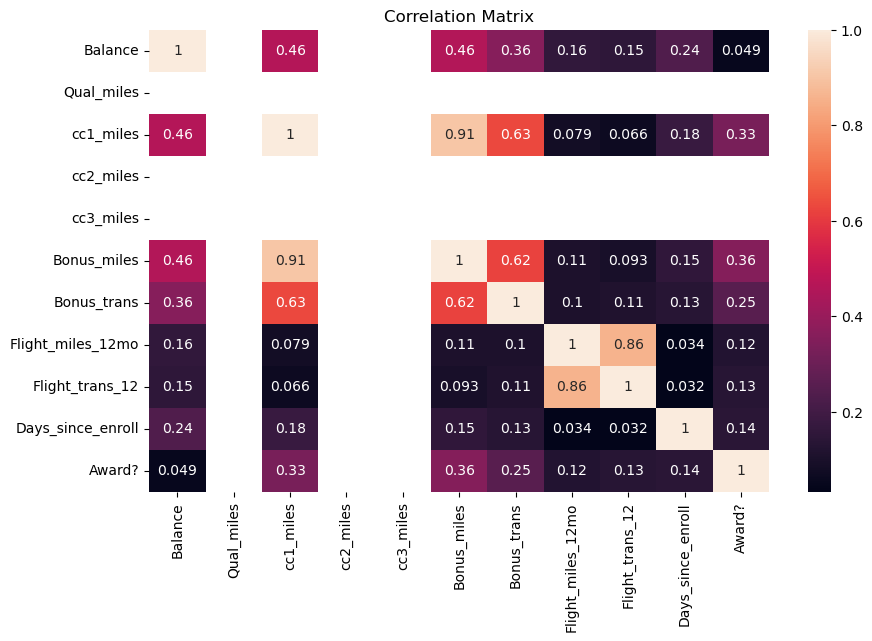

In [9]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True)
plt.title("Correlation Matrix")
plt.show()

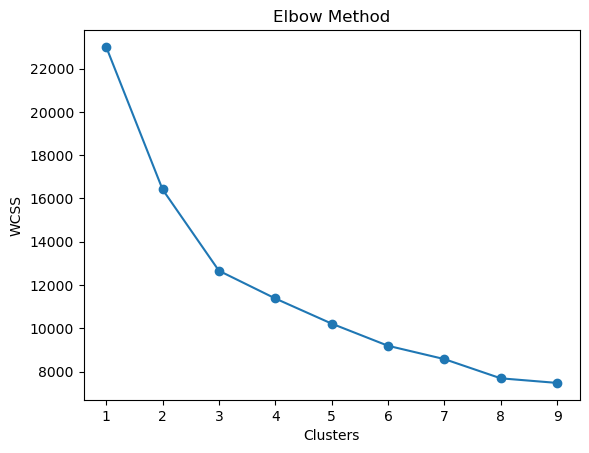

In [10]:
wcss = []

for i in range(1, 10):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(scaled_data)
    wcss.append(kmeans.inertia_)

plt.plot(range(1,10), wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("Clusters")
plt.ylabel("WCSS")
plt.show()

In [11]:
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans_labels = kmeans.fit_predict(scaled_data)

df['KMeans_Cluster'] = kmeans_labels

In [12]:
silhouette_score(scaled_data, kmeans_labels)

0.34184773367504273

In [13]:
dbscan = DBSCAN(eps=1.5, min_samples=5)
db_labels = dbscan.fit_predict(scaled_data)

df['DBSCAN_Cluster'] = db_labels

In [14]:
if len(set(db_labels)) > 1:
    print(silhouette_score(scaled_data, db_labels))
else:
    print("DBSCAN did not form proper clusters")

0.24853704856341488


In [15]:
eps_values = [0.5, 1.0, 1.5, 2.0]
min_samples_values = [3, 5, 10]

for eps in eps_values:
    for min_samples in min_samples_values:
        
        dbscan_test = DBSCAN(
            eps=eps,
            min_samples=min_samples
        )
        
        labels = dbscan_test.fit_predict(scaled_data)
        
        unique_clusters = len(set(labels))
        
        if unique_clusters > 1:
            score = silhouette_score(scaled_data, labels)
            
            print(
                "eps =", eps,
                ", min_samples =", min_samples,
                ", clusters =", unique_clusters,
                ", silhouette score =", round(score, 3)
            )
        
        else:
            print(
                "eps =", eps,
                ", min_samples =", min_samples,
                ", No proper clusters formed"
            )

eps = 0.5 , min_samples = 3 , clusters = 62 , silhouette score = -0.185
eps = 0.5 , min_samples = 5 , clusters = 20 , silhouette score = -0.13
eps = 0.5 , min_samples = 10 , clusters = 10 , silhouette score = -0.091
eps = 1.0 , min_samples = 3 , clusters = 24 , silhouette score = 0.05
eps = 1.0 , min_samples = 5 , clusters = 15 , silhouette score = 0.103
eps = 1.0 , min_samples = 10 , clusters = 4 , silhouette score = 0.213
eps = 1.5 , min_samples = 3 , clusters = 13 , silhouette score = 0.217
eps = 1.5 , min_samples = 5 , clusters = 8 , silhouette score = 0.249
eps = 1.5 , min_samples = 10 , clusters = 7 , silhouette score = 0.236
eps = 2.0 , min_samples = 3 , clusters = 7 , silhouette score = 0.265
eps = 2.0 , min_samples = 5 , clusters = 8 , silhouette score = 0.259
eps = 2.0 , min_samples = 10 , clusters = 6 , silhouette score = 0.264


In [16]:
pca = PCA(n_components=2)
pca_data = pca.fit_transform(scaled_data)

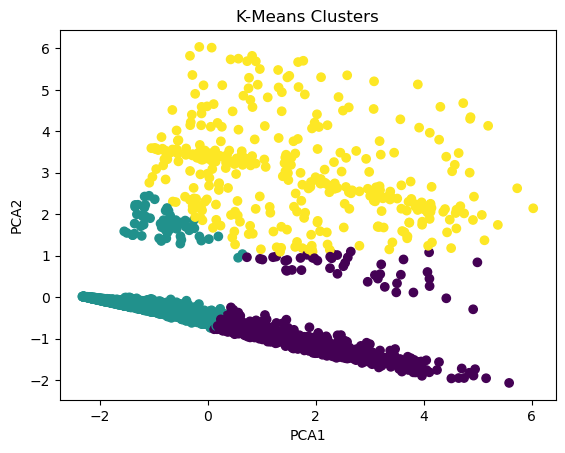

In [17]:
plt.scatter(pca_data[:,0], pca_data[:,1], c=kmeans_labels)
plt.title("K-Means Clusters")
plt.xlabel("PCA1")
plt.ylabel("PCA2")
plt.show()

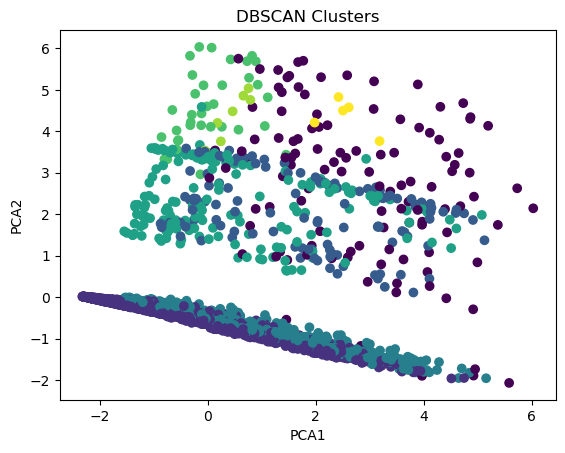

In [18]:
plt.scatter(pca_data[:,0], pca_data[:,1], c=db_labels)
plt.title("DBSCAN Clusters")
plt.xlabel("PCA1")
plt.ylabel("PCA2")
plt.show()

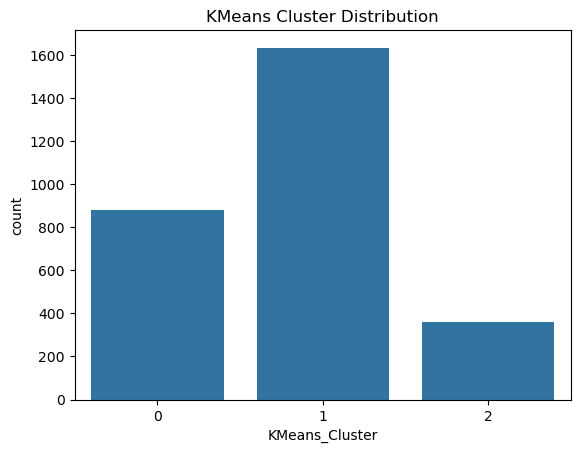

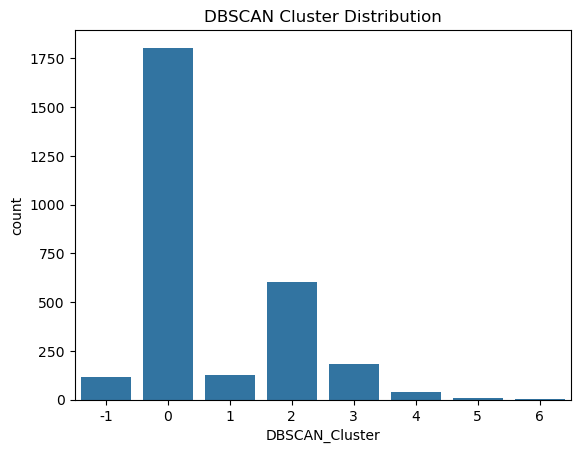

In [19]:
sns.countplot(x='KMeans_Cluster', data=df)
plt.title("KMeans Cluster Distribution")
plt.show()

sns.countplot(x='DBSCAN_Cluster', data=df)
plt.title("DBSCAN Cluster Distribution")
plt.show()

In [20]:
df.groupby('KMeans_Cluster').mean()

,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?,DBSCAN_Cluster
KMeans_Cluster,,,,,,,,,,,,
0,73089.693530,0.0,3.146425,1.0,1.0,24673.859251,15.995460,5.265607,0.049943,4550.239501,0.485812,0.926220
1,28586.860465,0.0,1.068543,1.0,1.0,2626.764994,5.305998,4.264994,0.035496,3551.556916,0.132803,0.346389
2,65452.516667,0.0,2.063889,1.0,1.0,14527.419444,11.727778,423.644444,1.302778,4105.566667,0.441667,1.622222


In [23]:
## K-Means Cluster Interpretation

### Cluster 0 – High Value Customers
- Customers have high balances and high bonus miles.
- They perform more bonus transactions.
- These are loyal and premium airline customers.

### Cluster 1 – Low Engagement Customers
- Customers have low balance and fewer transactions.
- Flight activity is very low.
- These customers are mostly inactive users.

### Cluster 2 – Moderate/Frequent Customers
- Customers have moderate balances and moderate bonus miles.
- Flight activity is higher than Cluster 1.
- These are regular airline users.

SyntaxError: invalid syntax (2438271470.py, line 4)

In [21]:
df.groupby('DBSCAN_Cluster').mean()

,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?,KMeans_Cluster
DBSCAN_Cluster,,,,,,,,,,,,
-1,103574.400000,0.0,2.626087,1.0,1.0,21837.817391,17.382609,368.356522,1.469565,4901.565217,0.617391,1.591304
0,42801.730194,0.0,1.567867,1.0,1.0,7473.067590,7.873684,0.000000,0.000000,3717.924100,0.000000,0.758449
1,41631.967742,0.0,2.411290,1.0,1.0,19086.629032,11.838710,338.854839,1.000000,4091.209677,1.000000,1.669355
2,46506.757475,0.0,2.431894,1.0,1.0,18152.727575,12.192691,0.000000,0.000000,4391.569767,1.000000,0.343854
3,57542.688889,0.0,1.694444,1.0,1.0,9664.983333,9.205556,322.661111,1.000000,3885.416667,0.000000,1.611111
4,39179.270270,0.0,1.027027,1.0,1.0,2568.972973,5.270270,433.486486,2.000000,3613.297297,0.000000,2.000000
5,24826.714286,0.0,1.000000,1.0,1.0,3270.857143,6.142857,396.142857,2.000000,2555.428571,1.000000,2.000000
6,71428.200000,0.0,3.200000,1.0,1.0,21422.000000,14.000000,570.000000,2.000000,2697.200000,0.000000,2.000000


In [ ]:
## DBSCAN Cluster Interpretation

### Cluster 0 – Low Activity Customers
- Very low flight activity.
- Minimal airline engagement.

### Cluster 1 & 2 – Loyal Customers
- Higher bonus miles and awards.
- Active loyalty program users.

### Cluster 3 – Occasional Travelers
- Moderate flight activity and moderate engagement.

### Cluster 4 & 5 – Low Balance but Active Flyers
- Lower balances but some travel activity.

### Cluster 6 – Premium Travelers
- Higher bonus miles and frequent airline usage.

### Noise Cluster (-1)
- Outlier customers with unusual behavior patterns.

In [22]:
df.to_csv("clustered_output.csv", index=False)

In [ ]:
# Conclusion

- K-Means achieved better clustering performance with a silhouette score of 0.34.
- DBSCAN identified density-based clusters and outliers.
- PCA visualization clearly showed separation between customer groups.
- Clustering helped identify loyal customers, inactive users, and premium travelers.
- These insights can help airlines improve customer retention and marketing strategies.